<a href="https://colab.research.google.com/github/roopa-r-yavagal/RRY-ml-assignment-2-breast-cancer/blob/main/ML_Assignment_2_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET OVERVIEW
----------------------------------------
Number of Rows    : 569
Number of Columns : 30 features + 1 target

MISSING VALUES
----------------------------------------
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst 

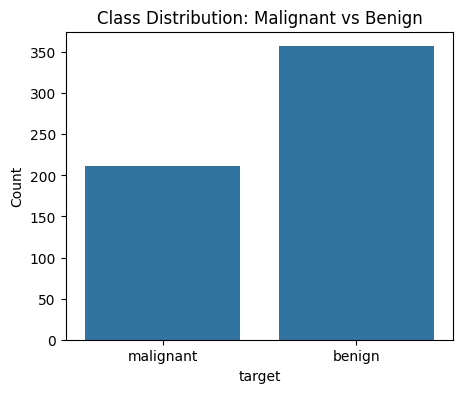


SUMMARY STATISTICS (first 5 features)
----------------------------------------
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


In [ ]:
# ============================================================
# STEP 1: Load Dataset and Perform Initial EDA
# ============================================================
# Dataset: Breast Cancer Wisconsin (Diagnostic)
# Source: sklearn.datasets (originally UCI ML Repository)
# Task: Binary classification - malignant (0) vs benign (1)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Combine into a single dataframe for EDA
df = X.copy()
df["target"] = y

# ------------------------------------------------------------
# DATASET OVERVIEW
# ------------------------------------------------------------
print("DATASET OVERVIEW")
print("-" * 40)
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1] - 1} features + 1 target")

# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------
print("\nMISSING VALUES")
print("-" * 40)
print(df.isnull().sum())

# ------------------------------------------------------------
# DATA TYPES
# ------------------------------------------------------------
print("\nDATA TYPES")
print("-" * 40)
print(df.dtypes)

# ------------------------------------------------------------
# CLASS BALANCE CHECK
# ------------------------------------------------------------
# target: 0 = malignant, 1 = benign (sklearn's default encoding)
print("\nCLASS BALANCE")
print("-" * 40)
class_counts = df["target"].value_counts()
class_pct = df["target"].value_counts(normalize=True) * 100
for cls in class_counts.index:
    label = data.target_names[cls]
    print(f"Class {cls} ({label}): {class_counts[cls]} samples ({class_pct[cls]:.1f}%)")

# Visualize class balance
plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=df)
plt.xticks([0, 1], data.target_names)
plt.title("Class Distribution: Malignant vs Benign")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------------------
# BASIC STATISTICS
# ------------------------------------------------------------
print("\nSUMMARY STATISTICS (first 5 features)")
print("-" * 40)
print(df.iloc[:, :5].describe())

In [ ]:
# ============================================================
# STEP 2: Label Flip, Train/Test Split, and Model Training
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

# ------------------------------------------------------------
# FLIP LABELS
# ------------------------------------------------------------
# sklearn's default: 0 = malignant, 1 = benign
# We flip so that: 1 = malignant (positive class, condition of interest)
#                  0 = benign (negative class)
y_flipped = 1 - y

print("Label mapping after flip:")
print("1 = malignant (positive class)")
print("0 = benign (negative class)")
print("\nNew class balance:")
print(y_flipped.value_counts())

# ------------------------------------------------------------
# TRAIN/TEST SPLIT
# ------------------------------------------------------------
# stratify=y_flipped ensures both train and test sets preserve
# the same malignant/benign ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_flipped, test_size=0.2, random_state=42, stratify=y_flipped
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Test set size    : {X_test.shape[0]} rows")

# ------------------------------------------------------------
# FEATURE SCALING
# ------------------------------------------------------------
# Logistic Regression and kNN are distance/gradient based and
# benefit from scaled features. Tree-based models (Decision Tree,
# Random Forest) and Naive Bayes don't strictly need scaling, but
# using the same scaled data across all models keeps the pipeline
# simple and doesn't hurt those models' performance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# DEFINE MODELS
# ------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
}

# ------------------------------------------------------------
# TRAIN, PREDICT, AND EVALUATE EACH MODEL
# ------------------------------------------------------------
results = []
trained_models = {}

for name, model in models.items():
    # Train on scaled data (consistent pipeline across all models)
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (malignant)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "AUC": round(auc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "MCC": round(mcc, 4),
    })

    print(f"\n{'=' * 50}")
    print(f"Model: {name}")
    print(f"{'=' * 50}")
    print(f"Accuracy : {acc:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"MCC      : {mcc:.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# ------------------------------------------------------------
# COMPARISON TABLE (for README)
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
print("\n\nCOMPARISON TABLE")
print("=" * 70)
print(results_df.to_string(index=False))

Label mapping after flip:
1 = malignant (positive class)
0 = benign (negative class)

New class balance:
target
0    357
1    212
Name: count, dtype: int64

Training set size: 455 rows
Test set size    : 114 rows

Model: Logistic Regression
Accuracy : 0.9649
AUC      : 0.9960
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512
MCC      : 0.9245

Confusion Matrix:
[[71  1]
 [ 3 39]]

Model: Decision Tree
Accuracy : 0.9298
AUC      : 0.9246
Precision: 0.9048
Recall   : 0.9048
F1 Score : 0.9048
MCC      : 0.8492

Confusion Matrix:
[[68  4]
 [ 4 38]]

Model: kNN
Accuracy : 0.9561
AUC      : 0.9823
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383
MCC      : 0.9058

Confusion Matrix:
[[71  1]
 [ 4 38]]

Model: Naive Bayes
Accuracy : 0.9211
AUC      : 0.9891
Precision: 0.9231
Recall   : 0.8571
F1 Score : 0.8889
MCC      : 0.8292

Confusion Matrix:
[[69  3]
 [ 6 36]]

Model: Random Forest
Accuracy : 0.9737
AUC      : 0.9929
Precision: 1.0000
Recall   : 0.9286
F1 Score : 0.9630
MCC      

In [ ]:
# ============================================================
# STEP 3: Save Trained Models and Scaler
# ============================================================
# These saved files will be loaded by the Streamlit app (app.py)
# so it doesn't need to retrain models every time it runs.

import joblib
import os

# Create a 'model' folder (matches the required repo structure)
os.makedirs("model", exist_ok=True)

# Save each trained model
for name, model in trained_models.items():
    # Turn "Logistic Regression" -> "logistic_regression.pkl" etc.
    filename = name.lower().replace(" ", "_") + ".pkl"
    filepath = os.path.join("model", filename)
    joblib.dump(model, filepath)
    print(f"Saved: {filepath}")

# Save the scaler too — the Streamlit app must scale any new
# uploaded data the SAME way the training data was scaled
scaler_path = os.path.join("model", "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"Saved: {scaler_path}")

# Save the comparison results table as well, so the app (or README)
# can load it directly without recomputing
results_df.to_csv(os.path.join("model", "model_comparison_results.csv"), index=False)
print(f"Saved: model/model_comparison_results.csv")

# ------------------------------------------------------------
# Also save the test data as CSV — this becomes your test_data.csv
# for the GitHub repo (assignment requires the test data you used)
# ------------------------------------------------------------
test_data = X_test.copy()
test_data["target"] = y_test.values  # 1 = malignant, 0 = benign (flipped labels)
test_data.to_csv("test_data.csv", index=False)
print("Saved: test_data.csv")

print("\nAll files saved. In Colab, check the file browser (left sidebar) —")
print("you'll see a 'model/' folder and 'test_data.csv' in the working directory.")
print("Download these (right-click > Download) to build your GitHub repo locally.")

Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/naive_bayes.pkl
Saved: model/random_forest.pkl
Saved: model/scaler.pkl
Saved: model/model_comparison_results.csv
Saved: test_data.csv

All files saved. In Colab, check the file browser (left sidebar) —
you'll see a 'model/' folder and 'test_data.csv' in the working directory.
Download these (right-click > Download) to build your GitHub repo locally.
